<a href="https://colab.research.google.com/github/Adhiaris/UAS-FINALTERM-FOR-DEEP-LEARNING-Text-Classification-NLI-/blob/main/Task1_Text_Classification_NLI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Install Dependencies


In [ ]:
!pip install transformers datasets evaluate accelerate seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
✅ All packages installed!


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
import evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found — enable GPU in Runtime settings.")
print(f"PyTorch: {torch.__version__}")

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
print(f"\nBase model : {MODEL_NAME}")
print(f"ax length  : {MAX_LENGTH} tokens")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
PyTorch: 2.11.0+cu128

Base model : distilbert-base-uncased
ax length  : 128 tokens


In [ ]:
accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    mask  = labels != -1
    preds, labels = preds[mask], labels[mask]
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1  = f1_metric.compute(predictions=preds, references=labels, average='macro')
    return {**acc, **f1}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Shared metrics ready.


## PART A — AG News Classification

### A1. Load & Explore Dataset

In [ ]:
dataset_ag = load_dataset('sh0416/ag_news')
print(dataset_ag)
print("\nSample entry:")
print(dataset_ag['train'][0])

README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

Sample entry:
{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}


Label mapping: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


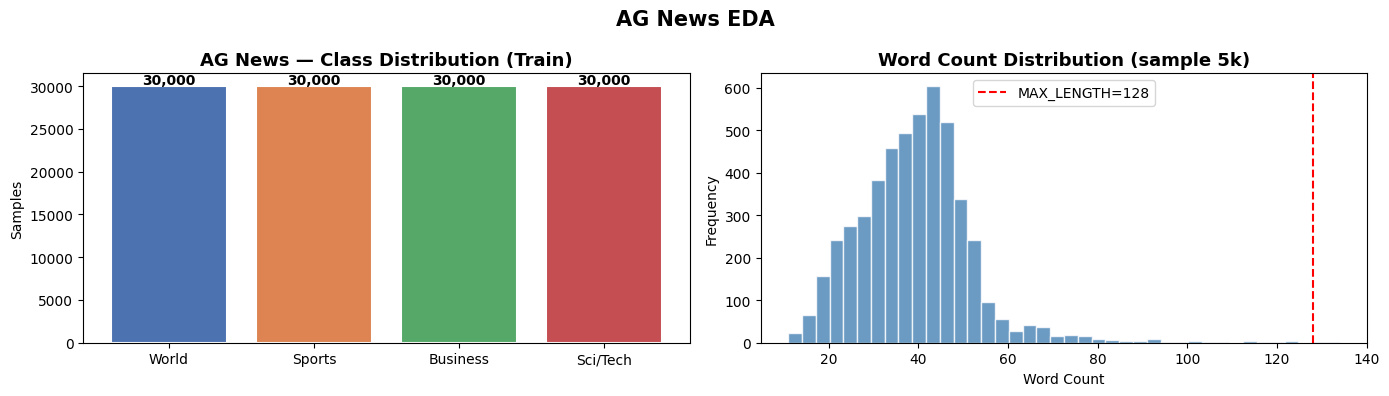

Mean length: 39 | 95th pct: 58 | MAX_LENGTH=128 ✅


In [ ]:
id2label_ag = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
label2id_ag = {v: k for k, v in id2label_ag.items()}
NUM_LABELS_AG = 4
print("Label mapping:", id2label_ag)


train_labels_raw = dataset_ag['train']['label']
label_counts_raw = Counter(train_labels_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))


categories = [id2label_ag[k] for k in sorted(id2label_ag.keys())]
counts     = [label_counts_raw[k+1] for k in sorted(id2label_ag.keys())]
colors     = ['#4C72B0','#DD8452','#55A868','#C44E52']
bars = axes[0].bar(categories, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('AG News — Class Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Samples')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{cnt:,}', ha='center', fontweight='bold', fontsize=10)


sample_texts = [f"{r['title']} {r['description']}" for r in dataset_ag['train'].select(range(5000))]
lengths = [len(t.split()) for t in sample_texts]
axes[1].hist(lengths, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(128, color='red', linestyle='--', label='MAX_LENGTH=128')
axes[1].set_title('Word Count Distribution (sample 5k)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('AG News EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('agnews_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean length: {np.mean(lengths):.0f} | 95th pct: {np.percentile(lengths,95):.0f} | MAX_LENGTH=128 ✅")

### A2. Tokenization

In [ ]:
tokenizer_ag = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME} | Vocab size: {tokenizer_ag.vocab_size:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: distilbert-base-uncased | Vocab size: 30,522


In [ ]:
def preprocess_ag(examples):
    texts  = [f"{t} {d}" for t, d in zip(examples['title'], examples['description'])]
    result = tokenizer_ag(texts, truncation=True, max_length=MAX_LENGTH, padding=False)
    result['label'] = [l - 1 for l in examples['label']]
    return result

tokenized_ag = dataset_ag.map(
    preprocess_ag, batched=True,
    remove_columns=['title', 'description']
)

USE_SUBSET = True
TRAIN_SIZE, TEST_SIZE = 20000, 2000

if USE_SUBSET:
    train_ag = tokenized_ag['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
    eval_ag  = tokenized_ag['test'].shuffle(seed=42).select(range(TEST_SIZE))
else:
    train_ag = tokenized_ag['train']
    eval_ag  = tokenized_ag['test']


labels_check = [ex['label'] for ex in train_ag.select(range(100))]
print(f"Labels after remap: {sorted(set(labels_check))} — expected [0,1,2,3]")
print(f"   Train: {len(train_ag):,} | Eval: {len(eval_ag):,}")

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Labels after remap: [0, 1, 2, 3] — expected [0,1,2,3]
   Train: 20,000 | Eval: 2,000


### A3. Model & Training

In [ ]:
torch.cuda.empty_cache()

model_ag = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS_AG,
    id2label=id2label_ag,
    label2id=label2id_ag,
    ignore_mismatched_sizes=True
).to(device)

params = sum(p.numel() for p in model_ag.parameters())
print(f"Model loaded: {MODEL_NAME}")
print(f"Total parameters: {params:,}")
print(f"Output classes  : {NUM_LABELS_AG}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
   Total parameters: 66,956,548
   Output classes  : 4


In [ ]:
data_collator_ag = DataCollatorWithPadding(tokenizer=tokenizer_ag)

training_args_ag = TrainingArguments(
    output_dir='/content/results/agnews',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=200,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=100,
    report_to='none',
    seed=42
)

trainer_ag = Trainer(
    model=model_ag,
    args=training_args_ag,
    train_dataset=train_ag,
    eval_dataset=eval_ag,
    data_collator=data_collator_ag,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

✅ Trainer AG News ready.


In [ ]:
train_result_ag = trainer_ag.train()
print(f"   Loss   : {train_result_ag.training_loss:.4f}")
print(f"   Runtime: {train_result_ag.metrics['train_runtime']:.0f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.267204,0.271240,0.908500,0.909378
2,0.192594,0.255396,0.916000,0.916873
3,0.141983,0.247901,0.921500,0.922433


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training complete!
   Loss   : 0.2658
   Runtime: 648s


### A4. Evaluation & Visualizations

In [ ]:
eval_results_ag = trainer_ag.evaluate(eval_ag)
print("Results:")
for k, v in eval_results_ag.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.141983,0.247901,3,0.921500,0.922433


📊 AG News Evaluation Results:
   eval_loss: 0.2479
   eval_accuracy: 0.9215
   eval_f1: 0.9224


📋 Classification Report:
              precision    recall  f1-score   support

       World       0.95      0.93      0.94       497
      Sports       0.98      0.99      0.98       483
    Business       0.88      0.88      0.88       522
    Sci/Tech       0.88      0.89      0.88       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



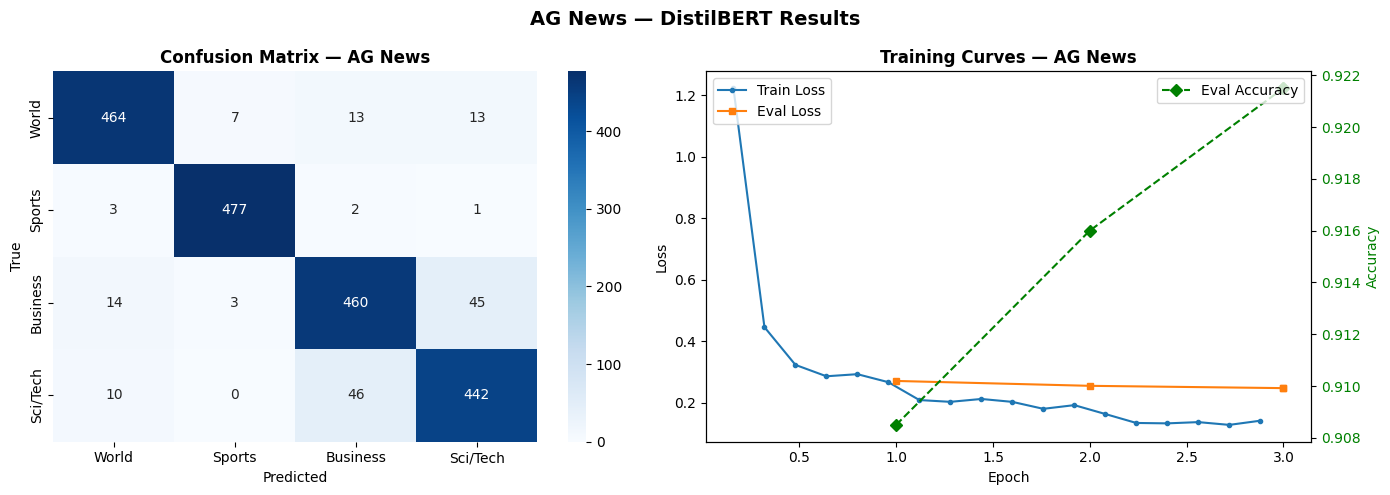

In [ ]:
preds_ag  = trainer_ag.predict(eval_ag)
y_pred_ag = np.argmax(preds_ag.predictions, axis=-1)
y_true_ag = preds_ag.label_ids

print("Classification Report:")
print(classification_report(y_true_ag, y_pred_ag, target_names=list(id2label_ag.values())))

cm_ag = confusion_matrix(y_true_ag, y_pred_ag)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_ag, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(id2label_ag.values()),
            yticklabels=list(id2label_ag.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix — AG News', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

logs = trainer_ag.state.log_history
train_loss = [(e['epoch'], e['loss']) for e in logs if 'loss' in e and 'eval_loss' not in e]
eval_loss  = [(e['epoch'], e['eval_loss']) for e in logs if 'eval_loss' in e]
eval_acc   = [(e['epoch'], e['eval_accuracy']) for e in logs if 'eval_accuracy' in e]
axes[1].plot(*zip(*train_loss), 'o-', label='Train Loss', markersize=3)
axes[1].plot(*zip(*eval_loss),  's-', label='Eval Loss',  markersize=5)
ax2b = axes[1].twinx()
ax2b.plot(*zip(*eval_acc), 'D--', color='green', label='Eval Accuracy', markersize=6)
ax2b.set_ylabel('Accuracy', color='green')
ax2b.tick_params(axis='y', labelcolor='green')
axes[1].set_title('Training Curves — AG News', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper left')
ax2b.legend(loc='upper right')

plt.suptitle('AG News — DistilBERT Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('agnews_results.png', dpi=150, bbox_inches='tight')
plt.show()

### A5. Inference Demo

In [ ]:
from transformers import pipeline

clf_ag = pipeline('text-classification', model=model_ag,
                   tokenizer=tokenizer_ag,
                   device=0 if torch.cuda.is_available() else -1)

test_sentences = [
    "NASA launches new Mars rover to search for signs of ancient life.",
    "The Federal Reserve raised interest rates by 25 basis points amid inflation concerns.",
    "Manchester City clinches the Premier League title with a 3-0 victory.",
    "Tensions rise in the South China Sea as naval fleets conduct exercises.",
    "Apple unveils the new M3 chip with breakthrough AI processing capabilities."
]

print("AG News Inference:")
print("─" * 65)
for text in test_sentences:
    r = clf_ag(text, truncation=True, max_length=MAX_LENGTH)[0]
    print(f"  [{r['label']:<10}] {r['score']:.3f}  →  {text[:60]}...")

🔍 AG News Inference:
─────────────────────────────────────────────────────────────────
  [Sci/Tech  ] 0.986  →  NASA launches new Mars rover to search for signs of ancient ...
  [Business  ] 0.991  →  The Federal Reserve raised interest rates by 25 basis points...
  [Sports    ] 0.990  →  Manchester City clinches the Premier League title with a 3-0...
  [World     ] 0.989  →  Tensions rise in the South China Sea as naval fleets conduct...
  [Sci/Tech  ] 0.982  →  Apple unveils the new M3 chip with breakthrough AI processin...


### A6. Save Model

In [ ]:
SAVE_AG = '/content/saved_models/agnews-distilbert'
model_ag.save_pretrained(SAVE_AG)
tokenizer_ag.save_pretrained(SAVE_AG)

metrics_ag = {
    'model': MODEL_NAME, 'dataset': 'AG News',
    'num_labels': NUM_LABELS_AG,
    'label_remap': '1-4 → 0-3',
    'train_samples': len(train_ag), 'eval_samples': len(eval_ag),
    'eval_accuracy': eval_results_ag.get('eval_accuracy'),
    'eval_f1_macro': eval_results_ag.get('eval_f1'),
    'eval_loss': eval_results_ag.get('eval_loss'),
    'hyperparams': {'epochs': 3, 'lr': 2e-5, 'batch_size': 32, 'max_len': 128}
}
with open('agnews_metrics.json', 'w') as f:
    json.dump(metrics_ag, f, indent=2)

print(f"Model saved  → {SAVE_AG}")
print(f"Metrics saved → agnews_metrics.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved  → /content/saved_models/agnews-distilbert
✅ Metrics saved → agnews_metrics.json


##PART B — GoEmotions Emotion Classification


### B1. Load & Explore Dataset

In [ ]:
dataset_go = load_dataset('google-research-datasets/go_emotions', 'simplified')
print(dataset_go)
print("\nSample:")
print(dataset_go['train'][0])

label_names_go = dataset_go['train'].features['labels'].feature.names
id2label_go    = {i: n for i, n in enumerate(label_names_go)}
label2id_go    = {n: i for i, n in enumerate(label_names_go)}
NUM_LABELS_GO  = len(label_names_go)
print(f"\nClasses ({NUM_LABELS_GO}): {label_names_go}")

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

📄 Sample:
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}

🏷️  Classes (28): ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

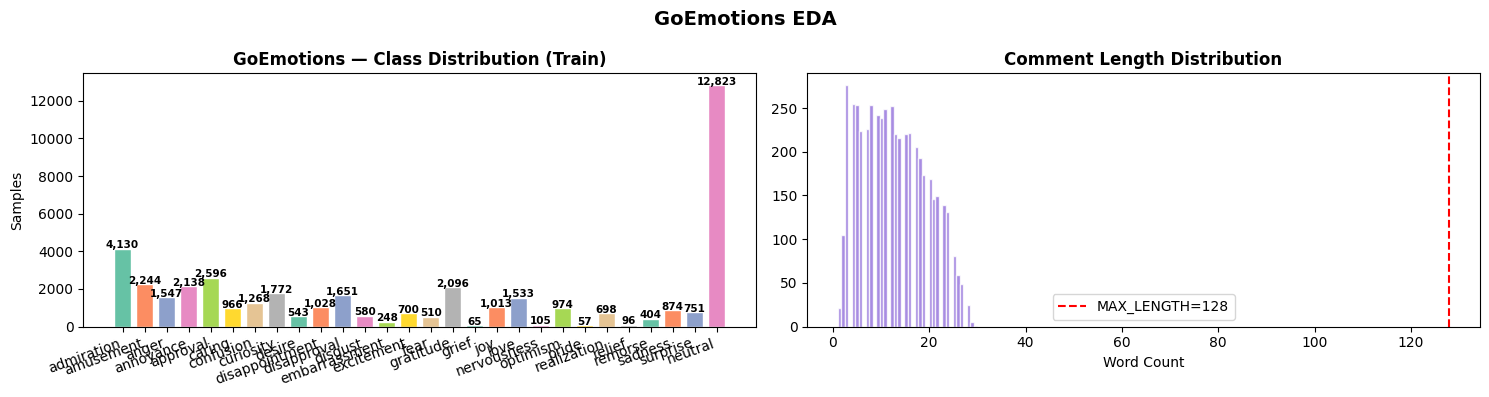

In [ ]:
def flatten_go(example):
    labels = example['labels']
    example['label'] = labels[0] if labels else label2id_go.get('neutral', 6)
    return example

dataset_go = dataset_go.map(flatten_go)

train_labels_go  = dataset_go['train']['label']
label_counts_go  = Counter(train_labels_go)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

emotions   = [id2label_go[k] for k in sorted(label_counts_go)]
counts_go  = [label_counts_go[k] for k in sorted(label_counts_go)]
palette    = sns.color_palette('Set2', NUM_LABELS_GO)
bars = axes[0].bar(emotions, counts_go, color=palette, edgecolor='white')
axes[0].set_title('GoEmotions — Class Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Samples')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')
for bar, cnt in zip(bars, counts_go):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{cnt:,}', ha='center', fontsize=7.5, fontweight='bold')

sample_go = [ex['text'] for ex in dataset_go['train'].select(range(5000))]
len_go    = [len(t.split()) for t in sample_go]
axes[1].hist(len_go, bins=40, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].axvline(128, color='red', linestyle='--', label='MAX_LENGTH=128')
axes[1].set_title('Comment Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.suptitle('GoEmotions EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('goemotions_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### B2. Tokenization

In [ ]:
tokenizer_go = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_go(examples):
    return tokenizer_go(examples['text'], truncation=True,
                        max_length=MAX_LENGTH, padding=False)

tokenized_go = dataset_go.map(
    preprocess_go, batched=True,
    remove_columns=['text', 'labels', 'id']
)

USE_SUBSET_GO = True
TRAIN_GO, EVAL_GO = 15000, 2000

if USE_SUBSET_GO:
    train_go = tokenized_go['train'].shuffle(seed=42).select(range(TRAIN_GO))
    eval_go  = tokenized_go['validation'].shuffle(seed=42).select(range(EVAL_GO))
else:
    train_go = tokenized_go['train']
    eval_go  = tokenized_go['validation']

print(f"Train: {len(train_go):,} | Eval: {len(eval_go):,}")

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

✅ Train: 15,000 | Eval: 2,000


### B3. Model & Training

In [ ]:
torch.cuda.empty_cache()

model_go = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS_GO,
    id2label=id2label_go,
    label2id=label2id_go,
    ignore_mismatched_sizes=True
).to(device)

print(f"Model loaded | Classes: {NUM_LABELS_GO} | Params: {sum(p.numel() for p in model_go.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded | Classes: 28 | Params: 66,975,004


In [ ]:
data_collator_go = DataCollatorWithPadding(tokenizer=tokenizer_go)

training_args_go = TrainingArguments(
    output_dir='/content/results/goemotions',
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=200,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    report_to='none',
    seed=42
)

trainer_go = Trainer(
    model=model_go,
    args=training_args_go,
    train_dataset=train_go,
    eval_dataset=eval_go,
    data_collator=data_collator_go,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

✅ Trainer GoEmotions ready.


In [ ]:
train_result_go = trainer_go.train()
print(f"   Loss   : {train_result_go.training_loss:.4f}")
print(f"   Runtime: {train_result_go.metrics['train_runtime']:.0f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.987231,1.766642,0.507500,0.225546
2,1.623803,1.569034,0.552500,0.345012
3,1.334324,1.531993,0.563500,0.376307
4,1.213115,1.530589,0.564000,0.385525


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training complete!
   Loss   : 1.6695
   Runtime: 357s


### B4. Evaluation & Visualizations

In [ ]:
eval_results_go = trainer_go.evaluate(eval_go)
print("GoEmotions Evaluation Results:")
for k, v in eval_results_go.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
1.213115,1.530589,4,0.564000,0.385525


📊 GoEmotions Evaluation Results:
   eval_loss: 1.5306
   eval_accuracy: 0.5640
   eval_f1: 0.3855


In [ ]:
preds_go  = trainer_go.predict(eval_go)
y_pred_go = np.argmax(preds_go.predictions, axis=-1)
y_true_go = preds_go.label_ids

print("Classification:")
print(classification_report(y_true_go, y_pred_go, target_names=label_names_go))

📋 Classification Report:
                precision    recall  f1-score   support

    admiration       0.65      0.77      0.70       177
     amusement       0.71      0.81      0.76       105
         anger       0.38      0.49      0.43        77
     annoyance       0.22      0.17      0.19        94
      approval       0.51      0.31      0.39       140
        caring       0.50      0.33      0.40        51
     confusion       0.56      0.29      0.38        51
     curiosity       0.49      0.61      0.54        84
        desire       0.70      0.35      0.47        20
disappointment       0.35      0.14      0.20        51
   disapproval       0.42      0.30      0.35        88
       disgust       0.38      0.12      0.18        25
 embarrassment       0.00      0.00      0.00        10
    excitement       0.36      0.20      0.26        20
          fear       0.79      0.44      0.57        34
     gratitude       0.86      0.90      0.88        93
         grief       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


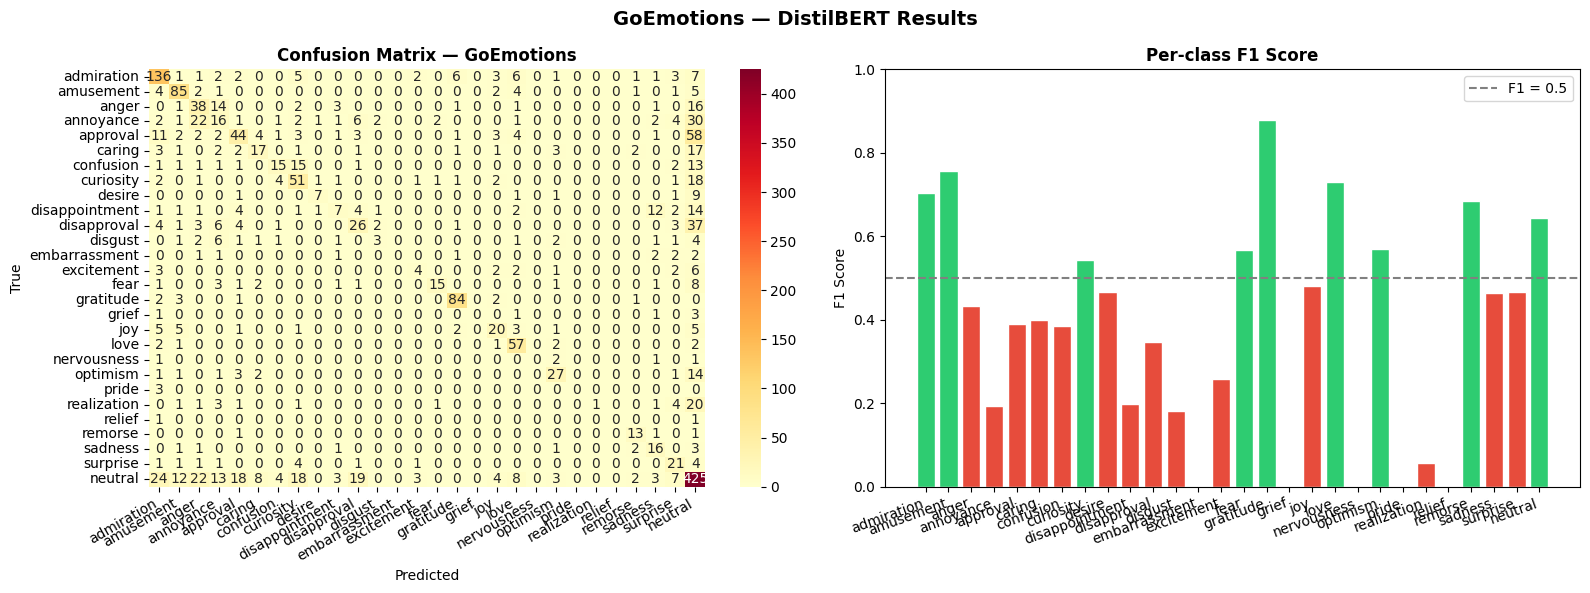

In [ ]:
per_class_f1 = f1_score(y_true_go, y_pred_go, average=None)
cm_go = confusion_matrix(y_true_go, y_pred_go)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_go, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=label_names_go,
            yticklabels=label_names_go, ax=axes[0])
axes[0].set_title('Confusion Matrix — GoEmotions', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

colors_f1 = ['#2ecc71' if f >= 0.5 else '#e74c3c' for f in per_class_f1]
axes[1].bar(label_names_go, per_class_f1, color=colors_f1, edgecolor='white')
axes[1].axhline(0.5, color='gray', linestyle='--', label='F1 = 0.5')
axes[1].set_title('Per-class F1 Score', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim([0, 1])
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.suptitle('GoEmotions — DistilBERT Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('goemotions_results.png', dpi=150, bbox_inches='tight')
plt.show()

### B5. Inference Demo

In [ ]:
clf_go = pipeline('text-classification', model=model_go,
                   tokenizer=tokenizer_go,
                   device=0 if torch.cuda.is_available() else -1)

test_comments = [
    "I can't believe I won! This is the best day of my life! 🎉",
    "I'm so disappointed with how things turned out. I feel let down.",
    "That's absolutely disgusting behavior, how can anyone do that?",
    "I'm really scared about what's going to happen next...",
    "Wait what?? I never saw that plot twist coming at all!",
    "Just another ordinary Monday, nothing special happening."
]

print("GoEmotions Inference:")
print("─" * 65)
for text in test_comments:
    r = clf_go(text, truncation=True, max_length=MAX_LENGTH)[0]
    print(f"  [{r['label']:<10}] {r['score']:.3f}  →  {text[:60]}...")

🔍 GoEmotions Inference:
─────────────────────────────────────────────────────────────────
  [admiration] 0.670  →  I can't believe I won! This is the best day of my life! 🎉...
  [sadness   ] 0.391  →  I'm so disappointed with how things turned out. I feel let d...
  [anger     ] 0.248  →  That's absolutely disgusting behavior, how can anyone do tha...
  [fear      ] 0.408  →  I'm really scared about what's going to happen next......
  [curiosity ] 0.452  →  Wait what?? I never saw that plot twist coming at all!...
  [neutral   ] 0.769  →  Just another ordinary Monday, nothing special happening....


### B6. Save Model

In [ ]:
SAVE_GO = '/content/saved_models/goemotions-distilbert'
model_go.save_pretrained(SAVE_GO)
tokenizer_go.save_pretrained(SAVE_GO)

metrics_go = {
    'model': MODEL_NAME, 'dataset': 'GoEmotions Simplified',
    'num_labels': NUM_LABELS_GO, 'label_names': label_names_go,
    'train_samples': len(train_go), 'eval_samples': len(eval_go),
    'eval_accuracy': eval_results_go.get('eval_accuracy'),
    'eval_f1_macro': eval_results_go.get('eval_f1'),
    'eval_loss': eval_results_go.get('eval_loss'),
    'hyperparams': {'epochs': 4, 'lr': 2e-5, 'batch_size': 32, 'max_len': 128}
}
with open('goemotions_metrics.json', 'w') as f:
    json.dump(metrics_go, f, indent=2)

print(f"Model saved  → {SAVE_GO}")
print(f"Metrics saved → goemotions_metrics.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved  → /content/saved_models/goemotions-distilbert
✅ Metrics saved → goemotions_metrics.json


##PART C — Natural Language Inference (NLI) on MNLI


### C1. Load & Explore MNLI

In [ ]:
dataset_mnli = load_dataset('nyu-mll/multi_nli')
print(dataset_mnli)
print("\nSample:")
print(dataset_mnli['train'][0])

README.md:   0%|          | 0.00/8.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/4.94M [00:00<?, ?B/s]

data/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9832
    })
})

📄 Sample:
{'promptID': 31193, 'pairID': '31193n', 'premise': 'Conceptually cream skimming has two basic dimensions - product and geography.', 'premise_binary_parse': '( ( Conceptually ( cream skimming ) ) ( ( has ( ( ( two ( basic dimensions ) ) - ) ( ( product and ) geography )

In [ ]:
id2label_mnli = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
label2id_mnli = {v: k for k, v in id2label_mnli.items()}
NUM_LABELS_MNLI = 3
print("NLI Labels:", id2label_mnli)


seen = set()
for ex in dataset_mnli['train']:
    lbl = ex['label']
    if lbl not in seen:
        seen.add(lbl)
        icons = {0:, 1:, 2:}
        print(f"{icons[lbl]} [{id2label_mnli[lbl].upper()}]")
        print(f"   Premise   : {ex['premise']}")
        print(f"   Hypothesis: {ex['hypothesis']}")
        print()
    if len(seen) == 3:
        break

🏷️  NLI Labels: {0: 'entailment', 1: 'neutral', 2: 'contradiction'}

📚 Example Pairs:

🤔 [NEUTRAL]
   Premise   : Conceptually cream skimming has two basic dimensions - product and geography.
   Hypothesis: Product and geography are what make cream skimming work. 

✅ [ENTAILMENT]
   Premise   : you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him
   Hypothesis: You lose the things to the following level if the people recall.

❌ [CONTRADICTION]
   Premise   : Gays and lesbians.
   Hypothesis: Heterosexuals.



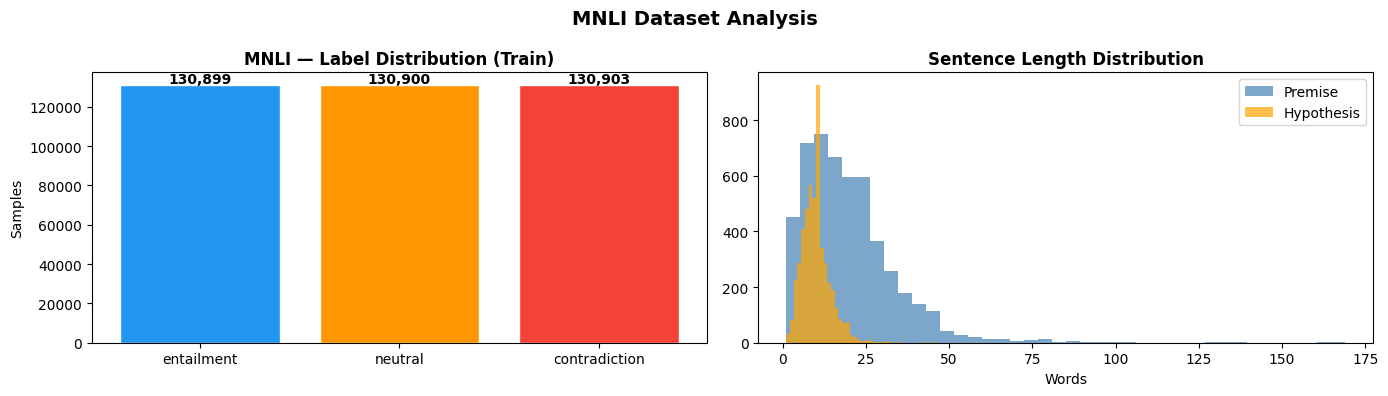

In [ ]:
train_labels_mnli = dataset_mnli['train']['label']
label_counts_mnli = Counter(train_labels_mnli)

sample_mnli  = dataset_mnli['train'].select(range(5000))
premise_lens = [len(p.split()) for p in sample_mnli['premise']]
hyp_lens     = [len(h.split()) for h in sample_mnli['hypothesis']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cats_mnli   = [id2label_mnli[k] for k in sorted(label_counts_mnli)]
counts_mnli = [label_counts_mnli[k] for k in sorted(label_counts_mnli)]
colors_mnli = ['#2196F3','#FF9800','#F44336']
bars = axes[0].bar(cats_mnli, counts_mnli, color=colors_mnli, edgecolor='white')
axes[0].set_title('MNLI — Label Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Samples')
for bar, cnt in zip(bars, counts_mnli):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'{cnt:,}', ha='center', fontweight='bold')

axes[1].hist(premise_lens, bins=40, alpha=0.7, label='Premise', color='steelblue')
axes[1].hist(hyp_lens,     bins=40, alpha=0.7, label='Hypothesis', color='orange')
axes[1].set_title('Sentence Length Distribution', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.suptitle('MNLI Dataset Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mnli_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### C2. Tokenization — Sentence Pairs

In [ ]:
tokenizer_mnli = AutoTokenizer.from_pretrained(MODEL_NAME)

demo = tokenizer_mnli(
    "The cat is sitting on the mat.",
    "There is an animal on the mat.",
    return_tensors='pt'
)
print("Sentence pair token format:")
print("  ", tokenizer_mnli.convert_ids_to_tokens(demo['input_ids'][0]))
print(f"\nTokenizer loaded | Vocab: {tokenizer_mnli.vocab_size:,}")

📌 Sentence pair token format:
   ['[CLS]', 'the', 'cat', 'is', 'sitting', 'on', 'the', 'mat', '.', '[SEP]', 'there', 'is', 'an', 'animal', 'on', 'the', 'mat', '.', '[SEP]']

✅ Tokenizer loaded | Vocab: 30,522


In [ ]:
def preprocess_mnli(examples):
    return tokenizer_mnli(
        examples['premise'],
        examples['hypothesis'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )


cols_to_remove = [c for c in dataset_mnli['train'].column_names
                  if c not in ('label',)]

tokenized_mnli = dataset_mnli.map(
    preprocess_mnli, batched=True,
    remove_columns=cols_to_remove
)
print(tokenized_mnli)

Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/9815 [00:00<?, ? examples/s]

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

✅ Tokenization complete!
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9832
    })
})


In [ ]:
USE_SUBSET_MNLI = True
TRAIN_MNLI, EVAL_MNLI = 25000, 3000

if USE_SUBSET_MNLI:
    train_mnli    = tokenized_mnli['train'].shuffle(seed=42).select(range(TRAIN_MNLI))
    eval_matched  = tokenized_mnli['validation_matched'].shuffle(seed=42).select(range(EVAL_MNLI))
    eval_mismatch = tokenized_mnli['validation_mismatched'].shuffle(seed=42).select(range(EVAL_MNLI))
else:
    train_mnli    = tokenized_mnli['train']
    eval_matched  = tokenized_mnli['validation_matched']
    eval_mismatch = tokenized_mnli['validation_mismatched']

print(f"Train: {len(train_mnli):,} | Matched: {len(eval_matched):,} | Mismatched: {len(eval_mismatch):,}")

✅ Train: 25,000 | Matched: 3,000 | Mismatched: 3,000


### C3. Model & Training

In [ ]:
torch.cuda.empty_cache()

model_mnli = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS_MNLI,
    id2label=id2label_mnli,
    label2id=label2id_mnli,
    ignore_mismatched_sizes=True
).to(device)

params = sum(p.numel() for p in model_mnli.parameters())
print(f"Model: {MODEL_NAME} | Classes: {NUM_LABELS_MNLI} | Params: {params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model: distilbert-base-uncased | Classes: 3 | Params: 66,955,779


In [ ]:
data_collator_mnli = DataCollatorWithPadding(tokenizer=tokenizer_mnli)

training_args_mnli = TrainingArguments(
    output_dir='/content/results/mnli',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=200,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=200,
    report_to='none',
    seed=42
)

trainer_mnli = Trainer(
    model=model_mnli,
    args=training_args_mnli,
    train_dataset=train_mnli,
    eval_dataset=eval_matched,
    data_collator=data_collator_mnli,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

✅ Trainer MNLI ready.


In [ ]:
train_result_mnli = trainer_mnli.train()
print(f"   Loss   : {train_result_mnli.training_loss:.4f}")
print(f"   Runtime: {train_result_mnli.metrics['train_runtime']:.0f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.812714,0.754644,0.671333,0.670123
2,0.638378,0.708419,0.702333,0.702491
3,0.490534,0.729592,0.710667,0.710154


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training complete!
   Loss   : 0.6765
   Runtime: 806s


### C4. Evaluation — Matched vs Mismatched

In [ ]:
print("=" * 50)
print("Matched Validation (in-domain):")
res_matched = trainer_mnli.evaluate(eval_matched)
for k, v in res_matched.items():
    if isinstance(v, float): print(f"   {k}: {v:.4f}")

print()
print("Mismatched Validation (cross-genre):")
res_mismatch = trainer_mnli.evaluate(eval_mismatch)
for k, v in res_mismatch.items():
    if isinstance(v, float): print(f"   {k}: {v:.4f}")
print("=" * 50)

📊 Matched Validation (in-domain):


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.490534,0.729592,3,0.710667,0.710154


   eval_loss: 0.7296
   eval_accuracy: 0.7107
   eval_f1: 0.7102

📊 Mismatched Validation (cross-genre):


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.490534,0.691690,3,0.725667,0.723777


   eval_loss: 0.6917
   eval_accuracy: 0.7257
   eval_f1: 0.7238


In [ ]:
preds_mnli = trainer_mnli.predict(eval_matched)
y_pred_mnli = np.argmax(preds_mnli.predictions, axis=-1)
y_true_mnli = preds_mnli.label_ids
mask = y_true_mnli != -1
y_pred_mnli, y_true_mnli = y_pred_mnli[mask], y_true_mnli[mask]

print("Classification Report (Matched Val):")
print(classification_report(y_true_mnli, y_pred_mnli, target_names=list(id2label_mnli.values())))

📋 Classification Report (Matched Val):
               precision    recall  f1-score   support

   entailment       0.77      0.74      0.76      1059
      neutral       0.64      0.71      0.67       972
contradiction       0.73      0.67      0.70       969

     accuracy                           0.71      3000
    macro avg       0.71      0.71      0.71      3000
 weighted avg       0.71      0.71      0.71      3000



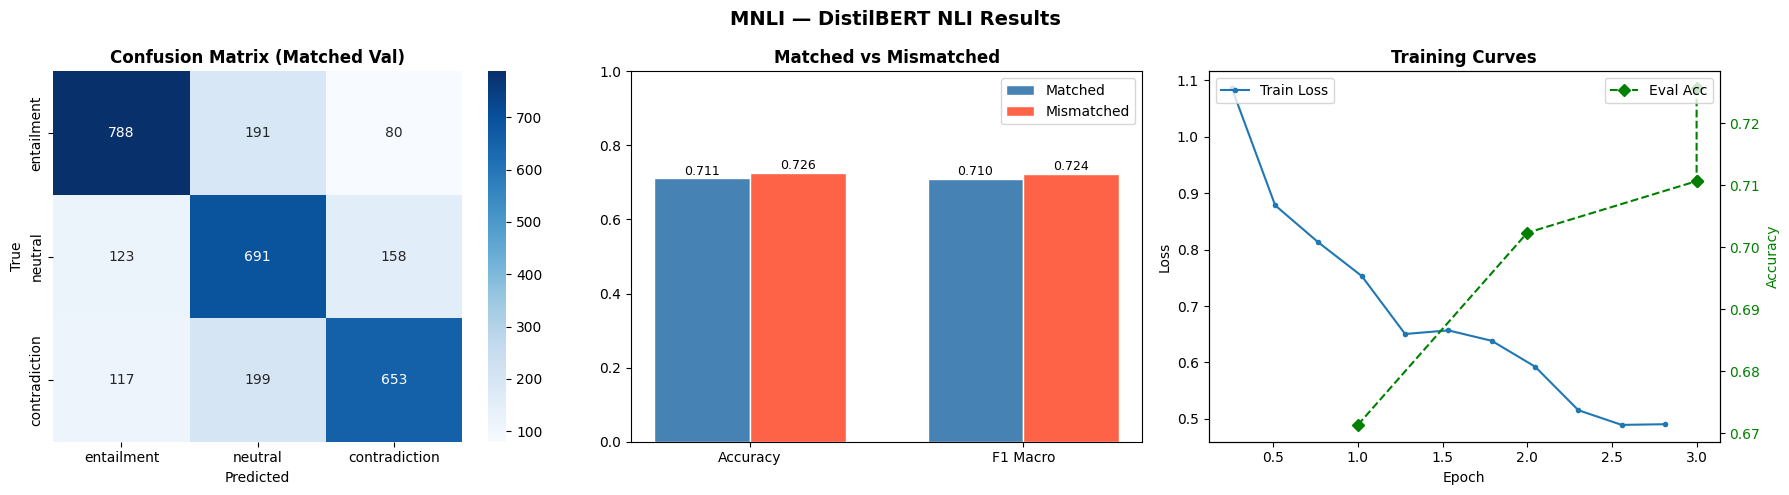

In [ ]:
cm_mnli = confusion_matrix(y_true_mnli, y_pred_mnli)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.heatmap(cm_mnli, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(id2label_mnli.values()),
            yticklabels=list(id2label_mnli.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Matched Val)', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

metrics_names  = ['Accuracy', 'F1 Macro']
matched_vals   = [res_matched.get('eval_accuracy',0), res_matched.get('eval_f1',0)]
mismatch_vals  = [res_mismatch.get('eval_accuracy',0), res_mismatch.get('eval_f1',0)]
x = np.arange(len(metrics_names))
w = 0.35
axes[1].bar(x-w/2, matched_vals,  w, label='Matched',    color='steelblue', edgecolor='white')
axes[1].bar(x+w/2, mismatch_vals, w, label='Mismatched', color='tomato',    edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_names)
axes[1].set_ylim([0,1])
axes[1].set_title('Matched vs Mismatched', fontweight='bold')
axes[1].legend()
for i,(m,mm) in enumerate(zip(matched_vals, mismatch_vals)):
    axes[1].text(i-w/2, m+0.01, f'{m:.3f}', ha='center', fontsize=9)
    axes[1].text(i+w/2, mm+0.01, f'{mm:.3f}', ha='center', fontsize=9)

logs_mnli  = trainer_mnli.state.log_history
train_loss = [(e['epoch'],e['loss']) for e in logs_mnli if 'loss' in e and 'eval_loss' not in e]
eval_acc   = [(e['epoch'],e['eval_accuracy']) for e in logs_mnli if 'eval_accuracy' in e]
axes[2].plot(*zip(*train_loss), 'o-', label='Train Loss', markersize=3)
ax2b = axes[2].twinx()
ax2b.plot(*zip(*eval_acc), 'D--', color='green', label='Eval Acc', markersize=6)
ax2b.set_ylabel('Accuracy', color='green')
ax2b.tick_params(axis='y', labelcolor='green')
axes[2].set_title('Training Curves', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend(loc='upper left')
ax2b.legend(loc='upper right')

plt.suptitle('MNLI — DistilBERT NLI Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mnli_results.png', dpi=150, bbox_inches='tight')
plt.show()

### C5. Inference Demo

In [ ]:
def predict_nli(premise, hypothesis):
    inputs = tokenizer_mnli(
        premise, hypothesis,
        return_tensors='pt', truncation=True, max_length=MAX_LENGTH
    ).to(device)
    with torch.no_grad():
        logits = model_mnli(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred  = np.argmax(probs)
    icons = {0:,1:,2:}
    label = id2label_mnli[pred]
    print(f"Premise   : {premise}")
    print(f"Hypothesis: {hypothesis}")
    print(f"Prediction: {icons[pred]} {label.upper()}")
    print(f"  P(entailment)={probs[0]:.3f} | P(neutral)={probs[1]:.3f} | P(contradiction)={probs[2]:.3f}")
    print()

test_pairs = [
    ("The dog is running in the park.", "An animal is moving outdoors."),
    ("The stock market closed higher on Friday.", "All investors lost money this week."),
    ("She ordered a vegetarian pizza.", "She is eating meat tonight."),
    ("The president signed the climate bill.", "Some climate legislation was enacted."),
]

print("NLI Predictions:")
print("=" * 65)
for p, h in test_pairs:
    predict_nli(p, h)

🔍 NLI Predictions:
Premise   : The dog is running in the park.
Hypothesis: An animal is moving outdoors.
Prediction: 🤔 NEUTRAL
  P(entailment)=0.249 | P(neutral)=0.498 | P(contradiction)=0.253

Premise   : The stock market closed higher on Friday.
Hypothesis: All investors lost money this week.
Prediction: 🤔 NEUTRAL
  P(entailment)=0.009 | P(neutral)=0.802 | P(contradiction)=0.189

Premise   : She ordered a vegetarian pizza.
Hypothesis: She is eating meat tonight.
Prediction: 🤔 NEUTRAL
  P(entailment)=0.024 | P(neutral)=0.939 | P(contradiction)=0.037

Premise   : The president signed the climate bill.
Hypothesis: Some climate legislation was enacted.
Prediction: ✅ ENTAILMENT
  P(entailment)=0.841 | P(neutral)=0.145 | P(contradiction)=0.014



### C6. Save Model

In [ ]:
SAVE_MNLI = '/content/saved_models/mnli-distilbert'
model_mnli.save_pretrained(SAVE_MNLI)
tokenizer_mnli.save_pretrained(SAVE_MNLI)

metrics_mnli = {
    'model': MODEL_NAME, 'dataset': 'MNLI (GLUE)',
    'task': 'Natural Language Inference',
    'num_labels': NUM_LABELS_MNLI,
    'train_samples': len(train_mnli),
    'eval_matched'   : {'accuracy': res_matched.get('eval_accuracy'),  'f1': res_matched.get('eval_f1')},
    'eval_mismatched': {'accuracy': res_mismatch.get('eval_accuracy'), 'f1': res_mismatch.get('eval_f1')},
    'hyperparams': {'epochs': 3, 'lr': 2e-5, 'batch_size': 32, 'max_len': 128}
}
with open('mnli_metrics.json', 'w') as f:
    json.dump(metrics_mnli, f, indent=2)

print(f"Model saved  → {SAVE_MNLI}")
print(f"Metrics saved → mnli_metrics.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved  → /content/saved_models/mnli-distilbert
✅ Metrics saved → mnli_metrics.json
